In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import pyswarms as ps
from deap import base,creator,tools,algorithms
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# =========================================================
# Section (A): Data loading and preprocessing
# =========================================================

In [6]:
# Load train and test datasets
train_data = pd.read_csv("loan_train.csv")
test_data  = pd.read_csv("loan_test.csv")

In [8]:
train_data.head(5)

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History,Area,Status
0,Male,No,0,Graduate,No,584900,0.0,15000000,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,458300,150800.0,12800000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,300000,0.0,6600000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,258300,235800.0,12000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,600000,0.0,14100000,360.0,1.0,Urban,Y


In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              601 non-null    object 
 1   Married             611 non-null    object 
 2   Dependents          599 non-null    object 
 3   Education           614 non-null    object 
 4   Self_Employed       582 non-null    object 
 5   Applicant_Income    614 non-null    int64  
 6   Coapplicant_Income  614 non-null    float64
 7   Loan_Amount         614 non-null    int64  
 8   Term                600 non-null    float64
 9   Credit_History      564 non-null    float64
 10  Area                614 non-null    object 
 11  Status              614 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 57.7+ KB


In [12]:
test_data.head(5)

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History,Area
0,Male,Yes,0,Graduate,No,572000,0,11000000,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,307600,150000,12600000,360.0,1.0,Urban
2,Male,Yes,2,Graduate,No,500000,180000,20800000,360.0,1.0,Urban
3,Male,Yes,2,Graduate,No,234000,254600,10000000,360.0,NaN,Urban
4,Male,No,0,Not Graduate,No,327600,0,7800000,360.0,1.0,Urban


In [14]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              356 non-null    object 
 1   Married             367 non-null    object 
 2   Dependents          357 non-null    object 
 3   Education           367 non-null    object 
 4   Self_Employed       344 non-null    object 
 5   Applicant_Income    367 non-null    int64  
 6   Coapplicant_Income  367 non-null    int64  
 7   Loan_Amount         367 non-null    int64  
 8   Term                361 non-null    float64
 9   Credit_History      338 non-null    float64
 10  Area                367 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 31.7+ KB


In [16]:
# Separate features and target variable
X = train_data.drop("Status", axis=1)
y = train_data["Status"]

In [18]:
# Fix Dependents like '3+' -> 3 (makes it numeric)
for df in (X, test_data):
    if "Dependents" in df.columns:
        df["Dependents"] = df["Dependents"].replace({"3+": "3"})

In [20]:
# Handle missing values in both datasets
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna(X[col].mode()[0])
        test_data[col] = test_data[col].fillna(test_data[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())
        test_data[col] = test_data[col].fillna(test_data[col].median())

In [34]:
# Encode categorical features
categorical_cols = X.select_dtypes(include=["object"]).columns
encoder = LabelEncoder()

for col in categorical_cols:
    encoder.fit(X[col])          # fit only on training data
    X[col] = encoder.transform(X[col])
    test_data[col] = encoder.transform(test_data[col])

# Encode target Status
y_le = LabelEncoder()
y = y_le.fit_transform(y.astype(str))  # e.g., N->0, Y->1

In [35]:
# Split training data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=53)

# model factory + evaluation metrics (Accuracy/Precision/Recall/F1)

In [38]:
SEED = 53
ALPHA = 0.5  # trade-off between accuracy and number of selected features

def make_rf(n_estimator,seed=53):
    return RandomForestClassifier(n_estimators=n_estimator,random_state=seed,n_jobs=-1,max_depth=10)

def evaluate_model(model, Xtr, ytr, Xte, yte, feature_mask=None):
    """Train on (Xtr,ytr) and evaluate on (Xte,yte).
    feature_mask: boolean mask over columns (length = n_features), or None for all features.
    """
    if feature_mask is not None:
        Xtr = Xtr.iloc[:, feature_mask]
        Xte = Xte.iloc[:, feature_mask]
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    out = {
        "accuracy": float(accuracy_score(yte, pred)),
        "precision": float(precision_score(yte, pred, zero_division=0)),
        "recall": float(recall_score(yte, pred, zero_division=0)),
        "f1": float(f1_score(yte, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(yte, pred),
    }
    return out


# =========================================================
# Section (B): Feature selection using PSO + Random Forest
# =========================================================

In [40]:
n_features = X_train.shape[1]

# continuous PSO

In [45]:
from pyswarms.single import GlobalBestPSO

options_cont = {"c1": 0.5, "c2": 0.3, "w": 0.9}

pso_cont = GlobalBestPSO(
    n_particles=50,
    dimensions=n_features,
    options=options_cont
)

def pso_cont_cost(particles):
    costs = []
    for particle in particles:
        mask = particle > 0.5  # threshold

        if mask.sum() == 0:
            costs.append(1.0)
            continue

        rf = make_rf(1,SEED)  
        metrics = evaluate_model(rf, X_train, y_train, X_val, y_val, feature_mask=mask)

        acc = metrics["accuracy"]
        feat_ratio = mask.sum() / n_features

        J = ALPHA * (1 - acc) + (1 - ALPHA) * feat_ratio
        costs.append(J)

    return np.array(costs)

best_cost_cont, best_pos_cont = pso_cont.optimize(pso_cont_cost, iters=100, verbose=False)

pso_cont_mask = best_pos_cont > 0.5
pso_cont_features = X.columns[pso_cont_mask].tolist()

print("PSO (continuous) best cost:", best_cost_cont)
print("PSO (continuous) selected features:", int(pso_cont_mask.sum()))
print("PSO selected features:", pso_cont_features)

PSO (continuous) best cost: 0.15085995085995085
PSO (continuous) selected features: 1
PSO selected features: ['Credit_History']


# Binary PSO

In [47]:
from pyswarms.discrete.binary import BinaryPSO

def binary_fitness_func(particles):
    """
    particles: (n_particles, n_features) with 0/1 values.

    """
    costs = []
    alpha = ALPHA  

    for particle in particles:
        selected = particle.astype(bool)

        # Penalize empty selection
        if selected.sum() == 0:
            costs.append(1.0)
            continue

        rf = make_rf(1,SEED)
        metrics = evaluate_model(rf, X_train, y_train, X_val, y_val, feature_mask=selected)

        acc = metrics["accuracy"]
        feature_ratio = selected.sum() / n_features

        # Objective (minimize)
        # Common + sensible:
        # J = alpha*(1-Acc) + (1-alpha)*(feature_ratio)
        cost = alpha * (1 - acc) + (1 - alpha) * feature_ratio
        costs.append(cost)

    return np.array(costs)

# PSO hyperparams (prompt suggestions + required keys for BinaryPSO)
options = {
    "c1": 0.5,
    "c2": 0.3,
    "w": 0.9,
    "k": 10,  # number of neighbors (required by pyswarms BinaryPSO)
    "p": 2    # Minkowski p-norm (usually 1 or 2)
}

optimizer = BinaryPSO(
    n_particles=50,
    dimensions=n_features,
    options=options
)

best_cost_pso, best_pos_pso = optimizer.optimize(binary_fitness_func, iters=100, verbose=False)

# Convert best position to mask + feature names (keep naming compatible)
pso_mask = best_pos_pso.astype(bool)
pso_features = X.columns[pso_mask].to_list()
pso_selected_features = pso_features

print("Selected features (BPSO):", pso_features)
print("Selected features:", int(pso_mask.sum()))
print("Best cost:", best_cost_pso)

Selected features (BPSO): ['Credit_History']
Selected features: 1
Best cost: 0.15085995085995085


# =========================================================
# Section (C): Feature selection using Genetic Algorithm (GA)
# =========================================================

In [50]:
from deap import base, creator, tools, algorithms

In [52]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

In [54]:
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual",tools.initRepeat,creator.Individual,toolbox.attr_bool,n=n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [56]:
def ga_fitness_func(individual):
    selected = np.array(individual, dtype=bool)

    if selected.sum() == 0:
        return (1,)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train.iloc[:, selected], y_train)

    acc = accuracy_score(y_val,model.predict(X_val.iloc[:, selected]))
    alpha = 0.5
    cost = alpha * (1 - acc) + (1 - alpha) * (selected.sum() / n_features)
    return (cost,)

In [58]:
toolbox.register("evaluate", ga_fitness_func)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

In [60]:
population = toolbox.population(n=50)

In [62]:
# Evaluate initial population
for ind in population:
    ind.fitness.values = toolbox.evaluate(ind)

In [64]:
# Main GA loop (track convergence)
best_per_gen = []
avg_per_gen  = []

for gen in range(50):
    # -------- Selection --------
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))

    # -------- Crossover --------
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.9:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    # -------- Mutation --------
    for mutant in offspring:
        if random.random() < 0.1:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # -------- Re-evaluation --------
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid_ind:
        ind.fitness.values = toolbox.evaluate(ind)

    # -------- Replacement --------
    population[:] = offspring

    # -------- Convergence stats --------
    costs = [ind.fitness.values[0] for ind in population]
    best_per_gen.append(min(costs))
    avg_per_gen.append(float(np.mean(costs)))


In [68]:
# Best individual
best_ind = tools.selBest(population, 1)[0]

ga_mask = np.array(best_ind, dtype=bool)
ga_features = X.columns[ga_mask].to_list()
ga_selected_features = ga_features  # keep name compatible with rest of notebook

# Best GA cost
best_cost_ga = best_ind.fitness.values[0]

print("GA best cost:", best_cost_ga)
print("GA selected features:", int(ga_mask.sum()))
print("GA selected features:", ga_features)

GA best cost: 0.15085995085995085
GA selected features: 1
GA selected features: ['Credit_History']


# =========================================================
# Section (D): Train Random Forest with selected features
# =========================================================

In [72]:
# -------------------------------------------------------------------
# (D) Evaluate RandomForest on selected features (Accuracy/Precision/Recall/F1)
# -------------------------------------------------------------------
rf_pso = make_rf(300,SEED)
rf_ga  = make_rf(300,SEED)
rf_all = make_rf(300,SEED)

metrics_pso = evaluate_model(rf_pso, X_train, y_train, X_val, y_val, feature_mask=pso_mask)
metrics_ga  = evaluate_model(rf_ga,  X_train, y_train, X_val, y_val, feature_mask=ga_mask)
metrics_all = evaluate_model(rf_all, X_train, y_train, X_val, y_val, feature_mask=None)

summary = pd.DataFrame([
    {"method":"All features", "n_features": int(n_features), **{k:metrics_all[k] for k in ["accuracy","precision","recall","f1"]}},
    {"method":"PSO",          "n_features": int(pso_mask.sum()), **{k:metrics_pso[k] for k in ["accuracy","precision","recall","f1"]}},
    {"method":"GA",           "n_features": int(ga_mask.sum()),  **{k:metrics_ga[k]  for k in ["accuracy","precision","recall","f1"]}},
]).sort_values("f1", ascending=False)

display(summary)

,method,n_features,accuracy,precision,recall,f1
1,PSO,1,0.789189,0.766234,0.975207,0.858182
2,GA,1,0.789189,0.766234,0.975207,0.858182
0,All features,11,0.756757,0.756757,0.925620,0.832714


In [74]:
print("=== Confusion matrices (Val) ===")
print("All features:\n", metrics_all["confusion_matrix"])
print("\nPSO:\n", metrics_pso["confusion_matrix"])
print("\nGA:\n", metrics_ga["confusion_matrix"])

print("\n=== Classification report (best method on Val) ===")
best_method = summary.iloc[0]["method"]

if best_method == "PSO":
    model = make_rf(50,SEED)
    mask = pso_mask
elif best_method == "GA":
    model = make_rf(50,SEED)
    mask = ga_mask
else:
    model = make_rf(50,SEED)
    mask = None

# rebuild preds for report (fit on train, report on val)
if mask is None:
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
else:
    model.fit(X_train.iloc[:, mask], y_train)
    pred = model.predict(X_val.iloc[:, mask])

print(classification_report(y_val, pred, zero_division=0, target_names=list(y_le.classes_)))

=== Confusion matrices (Val) ===
All features:
 [[ 28  36]
 [  9 112]]

PSO:
 [[ 28  36]
 [  3 118]]

GA:
 [[ 28  36]
 [  3 118]]

=== Classification report (best method on Val) ===
              precision    recall  f1-score   support

           0       0.90      0.44      0.59        64
           1       0.77      0.98      0.86       121

    accuracy                           0.79       185
   macro avg       0.83      0.71      0.72       185
weighted avg       0.81      0.79      0.77       185



# =========================================================
# Section (E): Feature importance 
# =========================================================

In [77]:
rf_all_full = make_rf(300,SEED)
rf_all_full.fit(X_train, y_train)

importances = pd.Series(rf_all_full.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 10 feature importances (RF on all features):")
display(importances.head(10))

print("\nPSO selected features vs top importances:")
if len(pso_features) > 0:
    display(importances.loc[pso_features].sort_values(ascending=False))
else:
    print("No features selected by PSO.")

print("\nGA selected features vs top importances:")
if len(ga_features) > 0:
    display(importances.loc[ga_features].sort_values(ascending=False))
else:
    print("No features selected by GA.")

Top 10 feature importances (RF on all features):


Credit_History        0.299555
Applicant_Income      0.178844
Loan_Amount           0.172105
Coapplicant_Income    0.112332
Area                  0.068645
Dependents            0.048622
Married               0.029743
Education             0.028768
Term                  0.024240
Gender                0.019996
dtype: float64


PSO selected features vs top importances:


Credit_History    0.299555
dtype: float64


GA selected features vs top importances:


Credit_History    0.299555
dtype: float64

# =========================================================
# Section (F): Convergence curves
# =========================================================

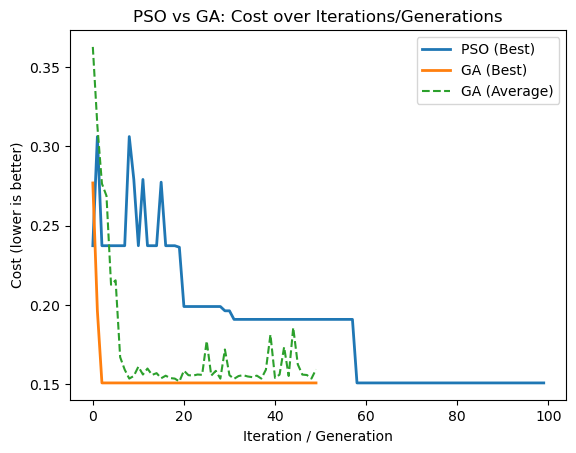

In [80]:
# --- Get PSO best-cost history ---
pso_history = getattr(optimizer, "cost_history", None)

plt.figure()

# PSO curve
if pso_history is not None:
    plt.plot(pso_history, label="PSO (Best)", linewidth=2)
else:
    print("PSO cost_history not available.")

# GA curves
plt.plot(best_per_gen, label="GA (Best)", linewidth=2)
# optional: show GA average too
plt.plot(avg_per_gen, label="GA (Average)", linestyle="--", linewidth=1.5)

plt.title("PSO vs GA: Cost over Iterations/Generations")
plt.xlabel("Iteration / Generation")
plt.ylabel("Cost (lower is better)")
plt.legend()
plt.show()

# =========================================================
# Train on FULL training set and predict the provided test set
# =========================================================

In [205]:
X_full = X.copy()
y_full = y.copy()

def train_and_predict(feature_list):
    if feature_list is None or len(feature_list) == 0:
        raise ValueError("Empty feature list. Cannot train a model with 0 features.")
    rf = make_rf(50,SEED)
    rf.fit(X_full[feature_list], y_full)
    preds = rf.predict(test_data[feature_list])
    # convert back to original labels (e.g., N/Y)
    return y_le.inverse_transform(preds)

pred_test_pso = train_and_predict(pso_features)
pred_test_ga  = train_and_predict(ga_features)

sub_pso = pd.DataFrame({"Status": pred_test_pso})
sub_ga  = pd.DataFrame({"Status": pred_test_ga})

# Save locally (and in some environments: /mnt/data is recommended)
sub_pso.to_csv("submission_pso.csv", index=False)
sub_ga.to_csv("submission_ga.csv", index=False)


display(sub_pso.head(),sub_ga.head())


,Status
0,Y
1,Y
2,Y
3,Y
4,Y


,Status
0,Y
1,Y
2,Y
3,Y
4,Y
